In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = np.array([2,4,1,6,3,8,5,9,3,7,3,5,7,3,9,0,60,2,5,7,88,9,0,1,900,3,5,777,4,32,46,4,3,33])

q1, q2, q3 = np.percentile(data, [25,50,75])



In [4]:
df = pd.DataFrame({"Values":data})
df

,Values
0,2
1,4
2,1
3,6
4,3
5,8
6,5
7,9
8,3
9,7


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Values  34 non-null     int64
dtypes: int64(1)
memory usage: 404.0 bytes


In [6]:
df.describe()

,Values
count,34.000000
mean,60.411765
std,198.930339
min,0.000000
25%,3.000000
50%,5.000000
75%,9.000000
max,900.000000


In [7]:
Q1 = df.quantile(0.25)
Q2 = df.quantile(0.50)
Q3 = df.quantile(0.75)
Q3

Values    9.0
Name: 0.75, dtype: float64

In [8]:
IQR = Q3 - Q1
IQR

Values    6.0
dtype: float64

In [9]:
lower = Q1 - IQR*0.25
upper = Q3 + IQR*0.75


In [10]:
outlier = (df["Values"] > int(upper)) | (df["Values"] < int(lower))
print(df[outlier])

    Values
15       0
16      60
20      88
22       0
24     900
27     777
29      32
30      46
33      33


C:\Users\Shantanu Pandya\AppData\Local\Temp\ipykernel_5588\2419375305.py:1: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  outlier = (df["Values"] > int(upper)) | (df["Values"] < int(lower))


In [29]:
df2 = pd.read_csv('Iris.csv')
# df2 = pd.DataFrame({"Values":d})

des = df2.describe()

Qq1 = df2[["SepalLengthCm"]].quantile(0.25)
Qq2 = df2[["SepalLengthCm"]].quantile(0.50)
Qq3 = df2[["SepalLengthCm"]].quantile(0.75)

IQR2 = Qq3 - Qq1

lower1 = Qq1 - IQR2*0.25
upper2 = Qq3 + IQR2*0.75

# l = [Qq1.values, Qq2.values, Qq3.values]
# l

# outlier2 = ((df2[["SepalLengthCm"]] > upper2) | (df2[["SepalLengthCm"]] < lower1))
# print(outlier2+)
out = np.where((df2[["SepalLengthCm"]] > upper2) | (df2[["SepalLengthCm"]] < lower1), df2[["SepalLengthCm"]],0)
out


array([[0. ],
       [0. ],
       [4.7],
       [4.6],
       [0. ],
       [0. ],
       [4.6],
       [0. ],
       [4.4],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [4.3],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [4.6],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [4.7],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [4.4],
       [0. ],
       [0. ],
       [4.5],
       [4.4],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [4.6],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
       [0. ],
      

c:\Users\Shantanu Pandya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


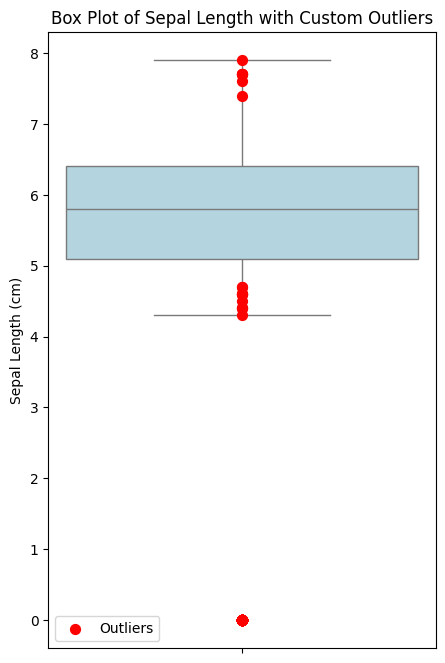

In [38]:
plt.figure(figsize=(5,8))
sns.boxplot(y=df2["SepalLengthCm"], color="lightblue", orient="h")

plt.scatter([0]*len(out), out, color="red", s=50, zorder=5, label="Outliers")

plt.title("Box Plot of Sepal Length with Custom Outliers")
plt.ylabel("Sepal Length (cm)")
plt.legend()
plt.show()